In [1]:
import pandas as pd


In [4]:
df = pd.read_excel(
    "solar_weather - Raw - Assignment Oct 2025-1.xlsx",
    sheet_name="solar_weather - Raw - Assignmen",
    engine="openpyxl"
)

df.head()


,Time,Energy Captured[Wh],Sun Light Intensity (W/m2),Temperature,1 Hour Rain Fall,Cloud Coverage,Length of Day_Light
0,2017-01-01 00:00:00,0,0,1.6,0,100,450
1,2017-01-01 00:15:00,0,0,1.6,0,100,450
2,2017-01-01 00:30:00,0,0,1.6,0,100,450
3,2017-01-01 00:45:00,0,0,1.6,0,100,450
4,2017-01-01 01:00:00,0,0,1.7,0,100,450


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196777 entries, 0 to 196776
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Time                        196777 non-null  object
 1   Energy Captured[Wh]         196777 non-null  object
 2   Sun Light Intensity (W/m2)  196777 non-null  object
 3   Temperature                 196777 non-null  object
 4   1 Hour Rain Fall            196777 non-null  object
 5   Cloud Coverage              196777 non-null  object
 6   Length of Day_Light         196777 non-null  object
dtypes: object(7)
memory usage: 10.5+ MB


In [6]:
# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Convert all other columns to numeric
numeric_columns = df.columns.drop('Time')
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Check again
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196777 entries, 0 to 196776
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Time                        196769 non-null  datetime64[ns]
 1   Energy Captured[Wh]         196773 non-null  float64       
 2   Sun Light Intensity (W/m2)  196770 non-null  float64       
 3   Temperature                 196771 non-null  float64       
 4   1 Hour Rain Fall            196773 non-null  float64       
 5   Cloud Coverage              196764 non-null  float64       
 6   Length of Day_Light         196772 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 10.5 MB


In [7]:
df.isnull().sum()


Time                           8
Energy Captured[Wh]            4
Sun Light Intensity (W/m2)     7
Temperature                    6
1 Hour Rain Fall               4
Cloud Coverage                13
Length of Day_Light            5
dtype: int64

In [8]:
# Handle missing values using forward fill
df = df.ffill()

# Check again
df.isnull().sum()


Time                          0
Energy Captured[Wh]           0
Sun Light Intensity (W/m2)    0
Temperature                   0
1 Hour Rain Fall              0
Cloud Coverage                0
Length of Day_Light           0
dtype: int64

In [9]:
# Sort data by time
df = df.sort_values(by='Time')

# Reset index
df = df.reset_index(drop=True)

# Quick check
df.head()


,Time,Energy Captured[Wh],Sun Light Intensity (W/m2),Temperature,1 Hour Rain Fall,Cloud Coverage,Length of Day_Light
0,2017-01-01 00:00:00,0.0,0.0,1.6,0.0,100.0,450.0
1,2017-01-01 00:15:00,0.0,0.0,1.6,0.0,100.0,450.0
2,2017-01-01 00:30:00,0.0,0.0,1.6,0.0,100.0,450.0
3,2017-01-01 00:45:00,0.0,0.0,1.6,0.0,100.0,450.0
4,2017-01-01 01:00:00,0.0,0.0,1.7,0.0,100.0,450.0


In [10]:
# Descriptive statistics: mean, median, mode, standard deviation

stats = pd.DataFrame({
    "Mean": df.drop(columns=['Time']).mean(),
    "Median": df.drop(columns=['Time']).median(),
    "Mode": df.drop(columns=['Time']).mode().iloc[0],
    "Std_Deviation": df.drop(columns=['Time']).std()
})

stats


,Mean,Median,Mode,Std_Deviation
Energy Captured[Wh],573.000839,0.0,0.0,1044.824408
Sun Light Intensity (W/m2),32.597356,1.6,0.0,52.174800
Temperature,9.790441,9.3,4.8,7.995474
1 Hour Rain Fall,0.066035,0.0,0.0,0.278913
Cloud Coverage,65.971719,82.0,100.0,36.637198
Length of Day_Light,748.642829,765.0,1020.0,194.870876


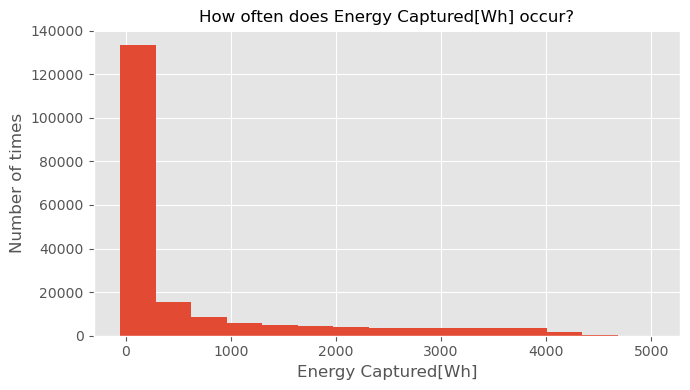

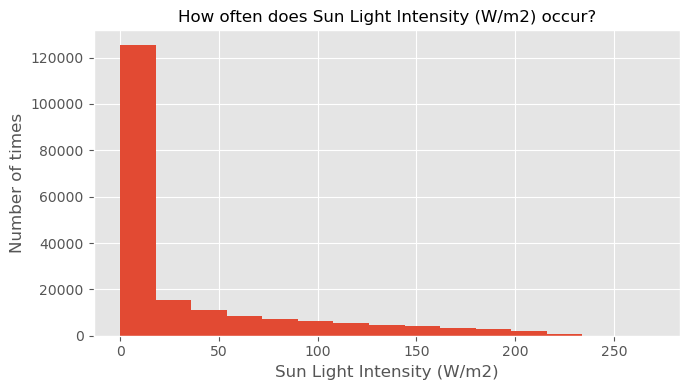

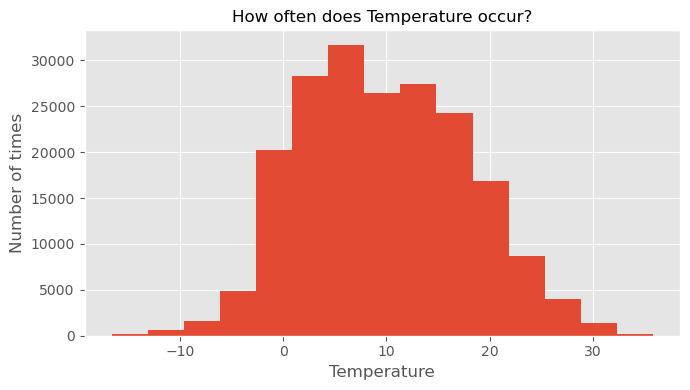

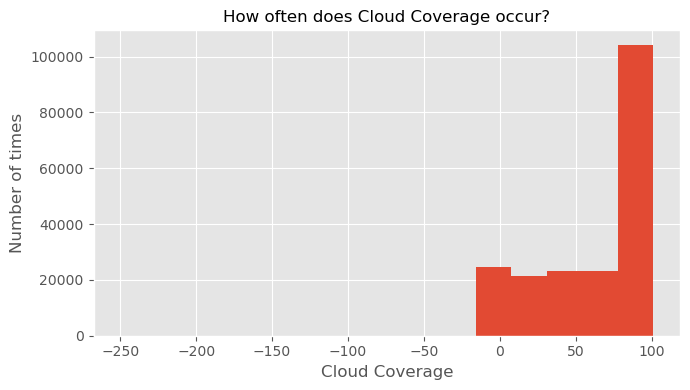

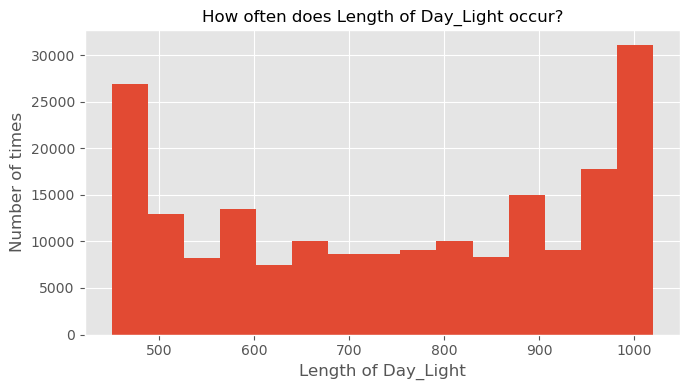

In [12]:
import matplotlib.pyplot as plt

# Make plots larger and clearer
plt.style.use('ggplot')

simple_columns = [
    'Energy Captured[Wh]',
    'Sun Light Intensity (W/m2)',
    'Temperature',
    'Cloud Coverage',
    'Length of Day_Light'
]

for col in simple_columns:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=15)   # fewer bins = simpler
    plt.title(f'How often does {col} occur?', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Number of times')
    plt.tight_layout()
    plt.show()


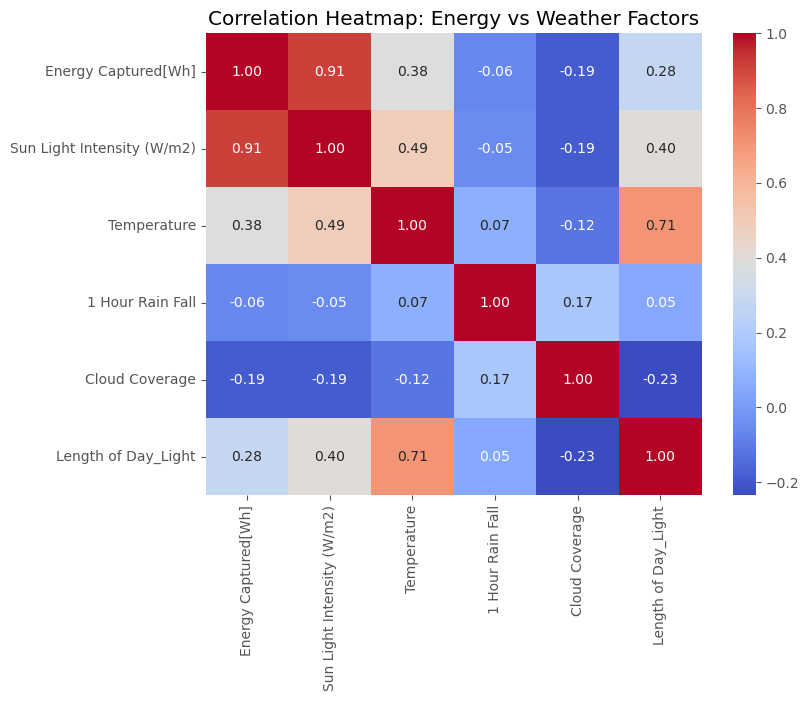

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove Time column (not numeric relationship)
corr = df.drop(columns=['Time']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap: Energy vs Weather Factors")
plt.show()


In [14]:
# Step 13: Define features (X) and target (y)

X = df[
    [
        "Sun Light Intensity (W/m2)",
        "Temperature",
        "1 Hour Rain Fall",
        "Cloud Coverage",
        "Length of Day_Light"
    ]
]

y = df["Energy Captured[Wh]"]

X.shape, y.shape


((196777, 5), (196777,))

In [15]:
# Step 14: Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((157421, 5), (39356, 5), (157421,), (39356,))

In [16]:
# Step 15: Feature Scaling (Normalization)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((157421, 5), (39356, 5))

In [17]:
# Step 16: Train Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()


In [18]:
lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [19]:
y_pred = lr_model.predict(X_test_scaled)

y_pred[:10]


array([1260.75909114, -179.321739  ,   95.42925253,  -99.33846044,
       1178.65901721, 3397.50763881,  113.37327436,  -19.16891731,
       2665.61240762, 2516.82533283])

In [20]:
# Step 17: Model Evaluation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [21]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2, mae, mse, rmse


(0.8471857431707193,
 241.98954906485758,
 168044.1341271527,
 np.float64(409.9318652253722))

In [22]:
# Step 18: Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor


In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


In [24]:
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [25]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_pred_rf[:10]


array([1360.89,    0.  ,  305.8 ,    0.  ,  992.63, 3647.58,    0.  ,
          0.  , 3081.  , 3056.21])

In [26]:
# Step 19: Evaluate Random Forest Model

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

r2_rf, mae_rf, mse_rf, rmse_rf


(0.9139550944690994,
 133.5695040024007,
 94620.37080837532,
 np.float64(307.60424380748606))

In [27]:
# Step 20: Model Comparison

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2, r2_rf],
    "MAE (Wh)": [mae, mae_rf],
    "RMSE (Wh)": [rmse, rmse_rf]
})

comparison_df


,Model,R2 Score,MAE (Wh),RMSE (Wh)
0,Linear Regression,0.847186,241.989549,409.931865
1,Random Forest,0.913955,133.569504,307.604244


In [28]:
# Ensure Time is datetime
df['Time'] = pd.to_datetime(df['Time'])

# Extract year and month
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# Filter only January data
jan_data = df[df['Month'] == 1]

# Calculate average energy per January per year
jan_avg = jan_data.groupby('Year')['Energy Captured[Wh]'].mean()

jan_avg


Year
2017    179.729275
2018    125.431452
2019    117.248992
2020    122.447245
2021     83.167339
2022    161.141204
Name: Energy Captured[Wh], dtype: float64

In [29]:
# Step 3A: Filter only January rows
df['Time'] = pd.to_datetime(df['Time'])
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

jan_data = df[df['Month'] == 1]

jan_data.shape


(16993, 9)

In [30]:
# Step 3C: Choose the same feature columns used for training
features = [
    'Sun Light Intensity (W/m2)',
    'Temperature',
    '1 Hour Rain Fall',
    'Cloud Coverage',
    'Length of Day_Light'
]

# Step 3C: Calculate average January weather values (historical)
jan_features_avg = jan_data[features].mean()

jan_features_avg


Sun Light Intensity (W/m2)      5.499017
Temperature                     1.280927
1 Hour Rain Fall                0.046068
Cloud Coverage                 79.308951
Length of Day_Light           486.777497
dtype: float64

In [31]:
# Step 3D: Convert average January values into a 1-row DataFrame
jan_2026_input = pd.DataFrame([jan_features_avg])

jan_2026_input


,Sun Light Intensity (W/m2),Temperature,1 Hour Rain Fall,Cloud Coverage,Length of Day_Light
0,5.499017,1.280927,0.046068,79.308951,486.777497


In [32]:
# Step 3E: Scale January 2026 input using the SAME scaler
jan_2026_scaled = scaler.transform(jan_2026_input)

jan_2026_scaled


array([[0.02036673, 0.34123907, 0.00569448, 0.93820214, 0.06452192]])

In [33]:
# Step 3F: Forecast average energy production for January 2026
jan_2026_forecast = rf_model.predict(jan_2026_scaled)[0]

jan_2026_forecast


np.float64(179.24)

In [34]:
# Step 4: Final January comparison table (exact requirement)

final_january_table = pd.DataFrame({
    "Year": [
        "Jan 2017", "Jan 2018", "Jan 2019",
        "Jan 2020", "Jan 2021", "Jan 2022",
        "Jan 2026 (Forecast)"
    ],
    "Average Energy Captured (Wh)": [
        179.729275,
        125.431452,
        117.248992,
        122.447245,
        83.167339,
        161.141204,
        179.24
    ]
})

final_january_table


,Year,Average Energy Captured (Wh)
0,Jan 2017,179.729275
1,Jan 2018,125.431452
2,Jan 2019,117.248992
3,Jan 2020,122.447245
4,Jan 2021,83.167339
5,Jan 2022,161.141204
6,Jan 2026 (Forecast),179.240000
